# Homework: Inverted Pendulum World Model Training

This notebook runs the official homework workflow: install dependencies, generate MuJoCo ground-truth windows, train the starter world model, evaluate locked nMSE/VPT scoreboard metrics, and plot diagnostics.

The assignment trains **one dynamics world model**. It does not train a policy, does not use reward, and does not use actor-critic updates.

The public scoreboard is for debugging and comparison. Official grading uses TA-private data generated with hidden seeds.

## 1. Configure Repository

If you are running this notebook inside a local clone, the setup cell will reuse the current repository. Otherwise, set `COURSE_REPO_URL` to your fork and the notebook will clone it.

In [11]:
from pathlib import Path
import os
import subprocess
import sys

# COURSE_REPO_URL = "https://github.com/WeijieLai1024/EEC289A_WorldModel-Homework.git"
# COURSE_REPO_BRANCH = "main"
SMOKE_RUN = False  # Full public profile by default.
RUN_SCOREBOARD_DEMO = True  # Generate/evaluate configs/public_scoreboard.yaml windows by default.

def run(cmd, cwd=None):
    cmd = [str(part) for part in cmd]
    print("+", " ".join(cmd))
    return subprocess.run(cmd, cwd=cwd, check=True)

# def find_existing_repo(start: Path):
#     for path in [start, *start.parents]:
#         if (path / "wm_hw").is_dir() and (path / "configs" / "dev.yaml").exists():
#             return path
#     return None

# def default_clone_dir():
#     content = Path("/content")
#     if content.exists() and os.access(content, os.W_OK):
#         return content / "wm_inverted_pendulum_hw"
#     return Path.home() / "wm_inverted_pendulum_hw"

# repo = find_existing_repo(Path.cwd())
# if repo is None:
#     repo = default_clone_dir()
#     if not (repo / ".git").exists():
#         run(["git", "clone", "--branch", COURSE_REPO_BRANCH, COURSE_REPO_URL, repo])
#     else:
#         print(f"Using existing repo at {repo}")

# COURSE_REPO_DIR = repo.resolve()
# print("COURSE_REPO_DIR =", COURSE_REPO_DIR)

## 2. Install Dependencies And Verify MuJoCo

In [1]:
# %cd {COURSE_REPO_DIR}
# !{sys.executable} -m pip install -q -U pip wheel "setuptools<82"
# !{sys.executable} -m pip install -q -r requirements.txt

import gymnasium as gym
import torch

env = gym.make("InvertedPendulum-v5", reset_noise_scale=0.01)
obs, info = env.reset(seed=0)
print("obs shape:", obs.shape)
print("action shape:", env.action_space.shape)
print("action range:", env.action_space.low, env.action_space.high)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
env.close()

obs shape: (4,)
action shape: (1,)
action range: [-3.] [3.]
torch: 2.9.1+cu128
cuda available: True


## 3. Run Tests

These tests check the environment, dataset schema, no-leak open-loop rollout, differentiable loss, locked VPT/nMSE metrics, and train/eval smoke path.

In [4]:
!{sys.executable} -m pytest -q -m "not slow"

.............                                                            [100%]
13 passed, 1 deselected in 2.67s


## 4. Generate MuJoCo Ground-Truth Windows

In [6]:
DATASET_DIR = "data/dev_smoke" if SMOKE_RUN else "data/dev"
smoke_flag = "--smoke" if SMOKE_RUN else ""
!{sys.executable} -m wm_hw.dataset --config configs/dev.yaml --output-dir {DATASET_DIR} {smoke_flag}

{                                                                               
  "output_dir": "data/dev",
  "written": {
    "train": "data/dev/train.npz",
    "val": "data/dev/val.npz",
    "test": "data/dev/test.npz",
    "ood": "data/dev/ood.npz"
  },
  "metadata": {
    "env_id": "InvertedPendulum-v5",
    "seed": 289,
    "smoke": false,
    "warmup_steps": 10,
    "max_horizon": 100,
    "window_states": 111,
    "window_actions": 110,
    "action_range": [
      -3.0,
      3.0
    ],
    "splits": {
      "train": {
        "states": [
          4096,
          111,
          4
        ],
        "actions": [
          4096,
          110,
          1
        ]
      },
      "val": {
        "states": [
          512,
          111,
          4
        ],
        "actions": [
          512,
          110,
          1
        ]
      },
      "test": {
        "states": [
          512,
          111,
          4
        ],
        "actions": [
          512,
          110,


## 5. Train The Starter World Model

In [7]:
!{sys.executable} -m wm_hw.train --config configs/student.yaml --model student --dataset-dir {DATASET_DIR} --output-dir artifacts/student {smoke_flag}

[train] model=student device=cuda updates=2000 smoke=False
[train] update=1 loss/total=1.9824 loss/one_step=1.0063 loss/rollout=0.9762 max_horizon=100.0000 nMSE_AUC=1.4588 nMSE@1=0.2096 step_nMSE@1=0.2096 nMSE@5=0.5370 step_nMSE@5=0.8211 nMSE@10=0.7433 step_nMSE@10=1.0633 nMSE@90=2.0346 step_nMSE@90=3.1731 nMSE@100=2.1579 step_nMSE@100=3.4705 VPT80@0.10=0.0000 VPT50@0.10=1.0000 VPT80@0.25=0.0000 VPT50@0.25=1.0000 VPT80@0.50=1.0000 VPT50@0.50=3.0000 warmup_steps=10.0000 one_step_rmse=0.0700 open_loop_rmse@horizon=0.2011
[train] update=200 loss/total=0.0345 loss/one_step=0.0072 loss/rollout=0.0273 max_horizon=100.0000 nMSE_AUC=266.8290 nMSE@1=0.0020 step_nMSE@1=0.0020 nMSE@5=0.0036 step_nMSE@5=0.0062 nMSE@10=0.0091 step_nMSE@10=0.0240 nMSE@90=916.7721 step_nMSE@90=4642.0698 nMSE@100=1399.6846 step_nMSE@100=6689.1064 VPT80@0.10=15.0000 VPT50@0.10=19.0000 VPT80@0.25=18.0000 VPT50@0.25=22.0000 VPT80@0.50=19.0000 VPT50@0.50=25.0000 warmup_steps=10.0000 one_step_rmse=0.0082 open_loop_rmse@hor

## 6. Evaluate Test And OOD VPT Scoreboard

In [8]:
!{sys.executable} -m wm_hw.eval_horizon --checkpoint-dir artifacts/student/best_checkpoint --dataset-dir {DATASET_DIR} --split test --horizon auto --eval-config configs/official_eval.yaml --output-dir artifacts/student/eval_test
!{sys.executable} -m wm_hw.eval_horizon --checkpoint-dir artifacts/student/best_checkpoint --dataset-dir {DATASET_DIR} --split ood --horizon auto --eval-config configs/official_eval.yaml --output-dir artifacts/student/eval_ood

{
  "metrics_summary": {
    "max_horizon": 100,
    "VPT80@0.25": 21,
    "VPT50@0.25": 25,
    "nMSE_AUC": 278.34417724609375,
    "nMSE@10": 0.002842700807377696,
    "nMSE@90": 970.62060546875,
    "nMSE@100": 1483.419921875,
    "step_nMSE@10": 0.0065513537265360355,
    "step_nMSE@100": 7115.7490234375,
    "one_step_rmse": 0.0059575242921710014,
    "open_loop_rmse@horizon": 5.894443988800049
  },
  "metrics_json": "artifacts/student/eval_test/metrics.json",
  "scoreboard_summary_json": "artifacts/student/eval_test/scoreboard_summary.json",
  "per_window_vpt_0p25": "artifacts/student/eval_test/per_window_vpt_0p25.npy"
}
{
  "metrics_summary": {
    "max_horizon": 100,
    "VPT80@0.25": 8,
    "VPT50@0.25": 14,
    "nMSE_AUC": 445.8018798828125,
    "nMSE@10": 0.12005802989006042,
    "nMSE@90": 1440.0865478515625,
    "nMSE@100": 2071.154296875,
    "step_nMSE@10": 0.30196526646614075,
    "step_nMSE@100": 8881.69140625,
    "one_step_rmse": 0.025172406807541847,
    "open_loop_

## 7. Plot Diagnostics

{'survival_curve': 'artifacts/student/plots/survival_curve.png', 'rollout_comparison': 'artifacts/student/plots/rollout_comparison.png'}
test VPT80@0.25: 21
ood VPT80@0.25: 8
test max_horizon: 100
test nMSE_AUC: 278.34417724609375


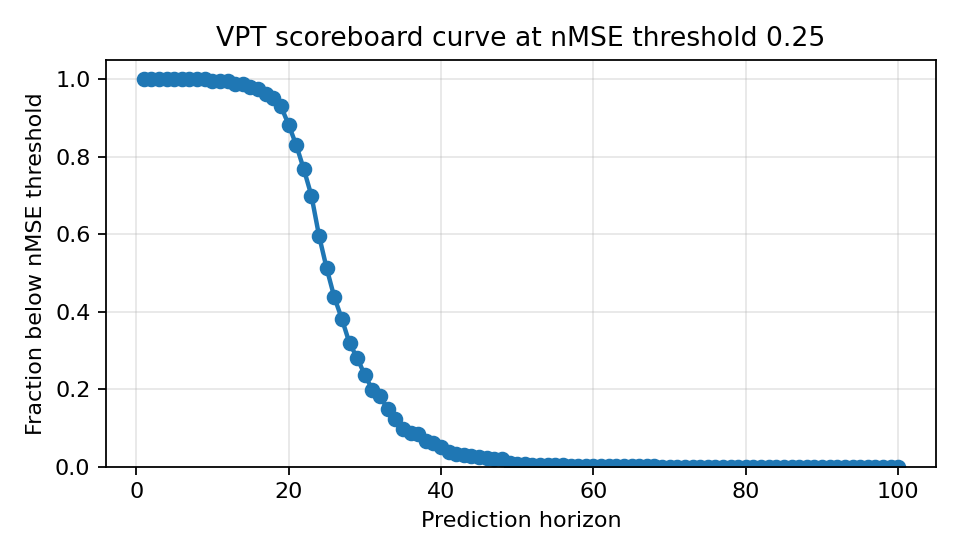

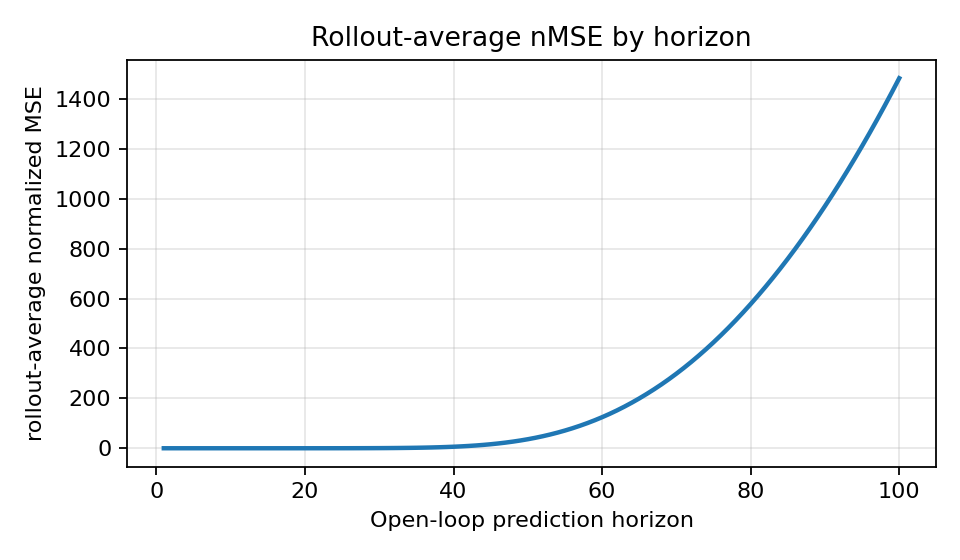

In [9]:
!{sys.executable} -m wm_hw.plotting --eval-dir artifacts/student/eval_test --output-dir artifacts/student/plots

import json
from IPython.display import Image, display

with open("artifacts/student/eval_test/metrics.json", "r", encoding="utf-8") as f:
    test_metrics = json.load(f)
with open("artifacts/student/eval_ood/metrics.json", "r", encoding="utf-8") as f:
    ood_metrics = json.load(f)

print("test VPT80@0.25:", test_metrics["VPT80@0.25"])
print("ood VPT80@0.25:", ood_metrics["VPT80@0.25"])
print("test max_horizon:", test_metrics["max_horizon"])
print("test nMSE_AUC:", test_metrics["nMSE_AUC"])
display(Image("artifacts/student/plots/survival_curve.png"))
display(Image("artifacts/student/plots/rollout_comparison.png"))

## 8. Optional Long-Horizon Scoreboard

The regular cells above stay lightweight. If you want the final public scoreboard artifacts, set `RUN_SCOREBOARD_DEMO = True` and `SMOKE_RUN = False` in the first cell. The public scoreboard config uses `warmup_steps=10` and `max_horizon=1000`.

In [12]:
if RUN_SCOREBOARD_DEMO:
    import json
    assert not SMOKE_RUN, "Final scoreboard artifacts require SMOKE_RUN = False."
    SCOREBOARD_DIR = "data/public_scoreboard"
    run([sys.executable, "-m", "wm_hw.dataset", "--config", "configs/public_scoreboard.yaml", "--output-dir", SCOREBOARD_DIR])
    run([sys.executable, "-m", "wm_hw.eval_horizon", "--checkpoint-dir", "artifacts/student/best_checkpoint", "--dataset-dir", SCOREBOARD_DIR, "--split", "test", "--horizon", "auto", "--eval-config", "configs/official_eval.yaml", "--output-dir", "artifacts/student/public_scoreboard_test"])
    run([sys.executable, "-m", "wm_hw.plotting", "--eval-dir", "artifacts/student/public_scoreboard_test", "--output-dir", "artifacts/student/public_scoreboard_plots"])
    run(["bash", "-lc", "cd artifacts/student && zip -qr final_artifacts.zip best_checkpoint eval_test eval_ood plots public_scoreboard_test public_scoreboard_plots"])
    with open("artifacts/student/public_scoreboard_test/scoreboard_summary.json", "r", encoding="utf-8") as f:
        print(json.load(f))
else:
    print("Set RUN_SCOREBOARD_DEMO = True in the first cell to run the long-horizon scoreboard demo.")

+ /home/toon/.pyenv/versions/eec_env/bin/python -m wm_hw.dataset --config configs/public_scoreboard.yaml --output-dir data/public_scoreboard


{
  "output_dir": "data/public_scoreboard",
  "written": {
    "train": "data/public_scoreboard/train.npz",
    "val": "data/public_scoreboard/val.npz",
    "test": "data/public_scoreboard/test.npz",
    "ood": "data/public_scoreboard/ood.npz"
  },
  "metadata": {
    "env_id": "InvertedPendulum-v5",
    "seed": 289,
    "smoke": false,
    "warmup_steps": 10,
    "max_horizon": 1000,
    "window_states": 1011,
    "window_actions": 1010,
    "action_range": [
      -3.0,
      3.0
    ],
    "splits": {
      "train": {
        "states": [
          1024,
          1011,
          4
        ],
        "actions": [
          1024,
          1010,
          1
        ]
      },
      "val": {
        "states": [
          256,
          1011,
          4
        ],
        "actions": [
          256,
          1010,
          1
        ]
      },
      "test": {
        "states": [
          256,
          1011,
          4
        ],
        "actions": [
          256,
          1010,
